# S3Eval: Paper Figures & Analysis

Generate figures for the paper.


In [234]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 9

RESULTS_BASE = os.path.join('..', '..', 'results')
INTR_LLM = os.path.join(RESULTS_BASE, 'semantic', 'intrinsic', 'llm-as-experts')
EXTR_LLM = os.path.join(RESULTS_BASE, 'semantic', 'extrinsic', 'llm-as-experts')
INTR_EMB = os.path.join(RESULTS_BASE, 'semantic', 'intrinsic', 'similarity')
EXTR_EMB = os.path.join(RESULTS_BASE, 'semantic', 'extrinsic', 'similarity')
FIG_DIR = os.path.join('..', '..', 'Fig')
os.makedirs(FIG_DIR, exist_ok=True)
print('Paths OK')


Paths OK


In [235]:
def compute_f1(fpath, label_key='label'):
    """Compute F1, precision, recall, accuracy from results jsonl."""
    ref_true = ref_false = bad_true = bad_false = ref_none = bad_none = 0
    if not os.path.exists(fpath):
        return None
    with open(fpath) as f:
        for line in f:
            if not line.strip(): continue
            r = json.loads(line)
            source = r.get('source', '')
            label = r.get(label_key)
            if source == 'reference':
                if label is True: ref_true += 1
                elif label is False: ref_false += 1
                else: ref_none += 1
            elif source == 'bad':
                if label is True: bad_true += 1
                elif label is False: bad_false += 1
                else: bad_none += 1
    total_ref = ref_true + ref_false + ref_none
    total_bad = bad_true + bad_false + bad_none
    if total_ref + total_bad == 0: return None
    tp, fn, fp, tn = ref_true, ref_false + ref_none, bad_true, bad_false
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    acc = (tp+tn)/(total_ref+total_bad)
    return {'f1': f1, 'prec': prec, 'rec': rec, 'acc': acc, 'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn,
            'ref_total': total_ref, 'bad_total': total_bad}

print('Helper loaded')


Helper loaded


## RQ1


### S1 and S2: Syntax and Solvability Pass Rate

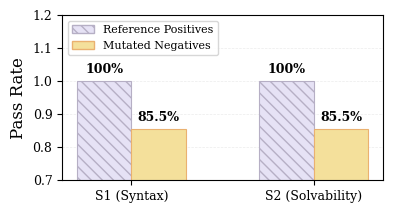

Saved to Fig/rq1_s1s2_pass_rate.png


In [236]:
# ── S1 & S2: Pass Rate on Reference vs Mutated Negatives ──
from matplotlib.patches import Patch

COLORS = {
    'red': (163/255, 81/255, 57/255),
    'dark_purple': (182/255, 175/255, 197/255),
    'dark_cyan': (182/255, 207/255, 212/255),
    'cyan': (225/255, 241/255, 246/255),
    'purple': (230/255, 226/255, 245/255),
    'orange': (244/255, 224/255, 155/255),
    'dark_orange': (234/255, 177/255, 112/255),
    'pink_red': (221/255, 185/255, 172/255),
}

# Data from S1 and S2 cells
# S1: TP=55, FN=0, FP=47, TN=8
# S2: TP=55, FN=0, FP=47, TN=8
ref_pass = [55/55, 55/55]       # 100%, 100%
bad_pass = [47/55, 47/55]       # 85.5%, 85.5%
labels = ['S1 (Syntax)', 'S2 (Solvability)']

BAR_WIDTH = 0.3
FIG_H = 2.2
FONT_SIZE_TICK = 12
TICK_LABEL_SIZE = 9

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(4, FIG_H))

bars1 = ax.bar(x - BAR_WIDTH/2, ref_pass, BAR_WIDTH,
               color=COLORS['purple'], edgecolor=COLORS['dark_purple'],
               hatch='\\\\\\', linewidth=0.8, zorder=2)
bars2 = ax.bar(x + BAR_WIDTH/2, bad_pass, BAR_WIDTH,
               color=COLORS['orange'], edgecolor=COLORS['dark_orange'],
               linewidth=0.8, zorder=2)

for bar, val in zip(bars1, ref_pass):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
            f'{val:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, bad_pass):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=TICK_LABEL_SIZE)
ax.set_ylabel('Pass Rate', fontsize=FONT_SIZE_TICK)
ax.set_ylim(0.7, 1.2)
ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
for y in np.arange(0.7, 1.2, 0.1):
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.15, zorder=0)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=COLORS['purple'], edgecolor=COLORS['dark_purple'], hatch='\\\\\\', label='Reference Positives'),
    Patch(facecolor=COLORS['orange'], edgecolor=COLORS['dark_orange'], label='Mutated Negatives'),
]
ax.legend(handles=legend_elements, loc='upper left', ncol=1, fontsize=8,
          frameon=True, edgecolor='lightgray', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rq1_s1s2_pass_rate.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'rq1_s1s2_pass_rate.pdf'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved to Fig/rq1_s1s2_pass_rate.png')

## S3


### S3: Embedding-based Similarity F1

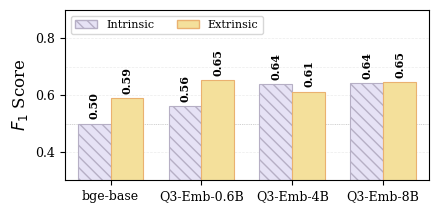

figsize=(4.46, 2.2)
Saved to Fig/rq1_emb_f1.png


In [237]:
# ── Embedding-based Similarity F1: Intrinsic vs Extrinsic (full matrix only) ──
from matplotlib.patches import Patch

COLORS = {
    'red': (163/255, 81/255, 57/255),
    'dark_purple': (182/255, 175/255, 197/255),
    'dark_cyan': (182/255, 207/255, 212/255),
    'cyan': (225/255, 241/255, 246/255),
    'purple': (230/255, 226/255, 245/255),
    'orange': (244/255, 224/255, 155/255),
    'dark_orange': (234/255, 177/255, 112/255),
    'pink_red': (221/255, 185/255, 172/255),
}

emb_models = ['bge-base', 'Qwen-Emb-0.6B', 'Qwen-Emb-4B', 'Qwen-Emb-8B']
emb_labels = ['bge-base', 'Q3-Emb-0.6B', 'Q3-Emb-4B', 'Q3-Emb-8B']

# Load intrinsic CV results
emb_cv_path = os.path.join(INTR_EMB, 'cv_intrinsic_similarity.jsonl')
emb_intr = {}
if os.path.exists(emb_cv_path):
    with open(emb_cv_path) as f:
        for line in f:
            if not line.strip(): continue
            r = json.loads(line)
            model, method, f1 = r.get('model',''), r.get('cv_method',''), r.get('f1',0)
            key = None
            if 'bge-base' in model: key = 'bge-base'
            elif 'Qwen3-Embedding-0.6B' in model: key = 'Qwen-Emb-0.6B'
            elif 'Qwen3-Embedding-4B' in model: key = 'Qwen-Emb-4B'
            elif 'Qwen3-Embedding-8B' in model: key = 'Qwen-Emb-8B'
            if key:
                if key not in emb_intr: emb_intr[key] = {}
                emb_intr[key][method] = f1

# Load extrinsic CV results
emb_extr_path = os.path.join(EXTR_EMB, 'cv_extrinsic_similarity.jsonl')
emb_extr = {}
if os.path.exists(emb_extr_path):
    with open(emb_extr_path) as f:
        for line in f:
            if not line.strip(): continue
            r = json.loads(line)
            model, f1 = r.get('model',''), r.get('f1',0)
            key = None
            if 'bge-base' in model: key = 'bge-base'
            elif 'Qwen3-Embedding-0.6B' in model: key = 'Qwen-Emb-0.6B'
            elif 'Qwen3-Embedding-4B' in model: key = 'Qwen-Emb-4B'
            elif 'Qwen3-Embedding-8B' in model: key = 'Qwen-Emb-8B'
            if key:
                emb_extr[key] = f1

# Styles
style_intr = {'fc': COLORS['purple'], 'ec': COLORS['dark_purple'], 'h': '\\\\\\', 'label': 'Intrinsic'}
style_extr = {'fc': COLORS['orange'], 'ec': COLORS['dark_orange'], 'h': '', 'label': 'Extrinsic'}

# ── Layout ──
BAR_WIDTH = 0.39
GROUP_GAP = 0.3
SCALE = 0.8
FIG_H = 2.2
FONT_SIZE_TICK = 12
TICK_LABEL_SIZE = 9

n = len(emb_models)
intr_step = 2 * BAR_WIDTH + GROUP_GAP
x = np.arange(n) * intr_step

x_pad = GROUP_GAP / 2
xlim = (x[0] - BAR_WIDTH - x_pad, x[-1] + BAR_WIDTH + x_pad)
data_w = xlim[1] - xlim[0]
fig_w = data_w * SCALE + 1.0

fig, ax = plt.subplots(figsize=(fig_w, FIG_H))

intr_vals = [emb_intr.get(m, {}).get('reference_full_matrix', 0) for m in emb_models]
extr_vals = [emb_extr.get(m, 0) for m in emb_models]

bars1 = ax.bar(x - BAR_WIDTH/2, intr_vals, BAR_WIDTH,
               color=style_intr['fc'], edgecolor=style_intr['ec'],
               hatch=style_intr['h'], linewidth=0.8, zorder=2)
bars2 = ax.bar(x + BAR_WIDTH/2, extr_vals, BAR_WIDTH,
               color=style_extr['fc'], edgecolor=style_extr['ec'],
               hatch=style_extr['h'], linewidth=0.8, zorder=2)

for bar, val in zip(bars1, intr_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')
for bar, val in zip(bars2, extr_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')

ax.set_xlim(xlim)
ax.set_xticks(x)
ax.set_xticklabels(emb_labels, rotation=0, ha='center', fontsize=TICK_LABEL_SIZE)
ax.set_ylabel('$F_1$ Score', fontsize=FONT_SIZE_TICK)
ax.set_ylim(0.3, 0.9)
ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
for y in np.arange(0.3, 0.95, 0.1):
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.15, zorder=0)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=0.6, alpha=0.4, zorder=0)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=style_intr['fc'], edgecolor=style_intr['ec'], hatch=style_intr['h'], label=style_intr['label']),
    Patch(facecolor=style_extr['fc'], edgecolor=style_extr['ec'], hatch=style_extr['h'], label=style_extr['label']),
]
ax.legend(handles=legend_elements, loc='upper left', ncol=2, fontsize=8,
          frameon=True, edgecolor='lightgray', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rq1_emb_f1.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'rq1_emb_f1.pdf'), dpi=600, bbox_inches='tight')
plt.show()
print(f'figsize=({fig_w:.2f}, {FIG_H})')
print('Saved to Fig/rq1_emb_f1.png')

### S3: LLM-as-Expert F1 + Token Cost — Intrinsic

In [238]:
# ── Collect all LLM results ──
llm_models = {
    # Local models (binary = simplified, scored = detailed)
    'Qwen3-4B': 'qwen3:4b',
    'Qwen3-8B': 'qwen3:8b',
    'Qwen3-14B': 'qwen3:14b',
    'Qwen3-32B': 'qwen3:32b',
    # Online models
    'GPT-4.1': 'gpt-4.1',
    'GPT-5.4': 'gpt-5.4',
    'GPT-5.5': 'gpt-5.5',
    'DS-R1': 'deepseek-reasoner',
}

results = {}
for display_name, model_id in llm_models.items():
    results[display_name] = {}
    for setting, base in [('intr', INTR_LLM), ('extr', EXTR_LLM)]:
        for mode, lkey in [('binary', 'label'), ('scored', 'verdict')]:
            fname = f'results_{"intrinsic" if setting=="intr" else "extrinsic"}_{mode}_{model_id}.jsonl'
            fpath = os.path.join(base, fname)
            r = compute_f1(fpath, lkey)
            key = f'{setting}_{mode}'
            results[display_name][key] = r
            if r:
                print(f'{display_name:15} {key:15} F1={r["f1"]:.3f} Ref={r["tp"]}/{r["ref_total"]} Bad={r["tn"]}/{r["bad_total"]}')
            else:
                print(f'{display_name:15} {key:15} NO DATA')


Qwen3-4B        intr_binary     F1=0.693 Ref=52/55 Bad=12/55
Qwen3-4B        intr_scored     F1=0.711 Ref=54/55 Bad=12/55
Qwen3-4B        extr_binary     F1=0.739 Ref=51/55 Bad=23/55
Qwen3-4B        extr_scored     F1=0.734 Ref=51/55 Bad=22/55
Qwen3-8B        intr_binary     F1=0.702 Ref=53/55 Bad=12/55
Qwen3-8B        intr_scored     F1=0.715 Ref=49/55 Bad=22/55
Qwen3-8B        extr_binary     F1=0.766 Ref=54/55 Bad=23/55
Qwen3-8B        extr_scored     F1=0.777 Ref=54/55 Bad=25/55
Qwen3-14B       intr_binary     F1=0.693 Ref=53/55 Bad=10/55
Qwen3-14B       intr_scored     F1=0.730 Ref=54/55 Bad=16/55
Qwen3-14B       extr_binary     F1=0.794 Ref=54/55 Bad=28/55
Qwen3-14B       extr_scored     F1=0.780 Ref=55/55 Bad=24/55
Qwen3-32B       intr_binary     F1=0.643 Ref=45/55 Bad=15/55
Qwen3-32B       intr_scored     F1=0.718 Ref=51/55 Bad=19/55
Qwen3-32B       extr_binary     F1=0.797 Ref=55/55 Bad=27/55
Qwen3-32B       extr_scored     F1=0.775 Ref=55/55 Bad=23/55
GPT-4.1         intr_bin

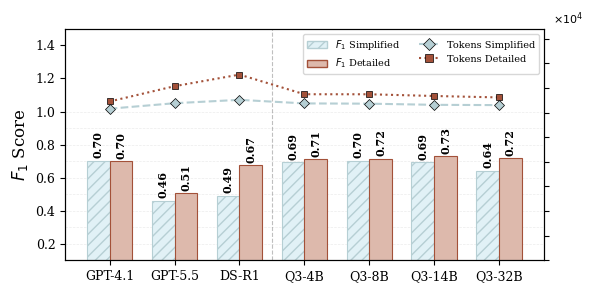

Saved to Fig/rq1_llm_f1_intrinsic.png


In [239]:
# ── RQ1: LLM-as-Expert F1 + Token Cost — Intrinsic ──
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

COLORS = {
    'red': (163/255, 81/255, 57/255),
    'dark_pink': (202/255, 162/255, 173/255),
    'dark_orange': (234/255, 177/255, 112/255),
    'dark_purple': (182/255, 175/255, 197/255),
    'dark_cyan': (182/255, 207/255, 212/255),
    'cyan': (225/255, 241/255, 246/255),
    'purple': (230/255, 226/255, 245/255),
    'orange': (244/255, 224/255, 155/255),
    'pink': (246/255, 223/255, 224/255),
    'pink_red': (221/255, 185/255, 172/255),
}

model_order = ['GPT-4.1', 'GPT-5.5', 'DS-R1', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B', 'Qwen3-32B']
model_labels = ['GPT-4.1', 'GPT-5.5', 'DS-R1', 'Q3-4B', 'Q3-8B', 'Q3-14B', 'Q3-32B']

# Avg tokens per sample — intrinsic
model_tokens_binary = {
    'GPT-4.1': 5792, 'GPT-5.5': 6904, 'DS-R1': 7591,
    'Qwen3-4B': 6865, 'Qwen3-8B': 6813, 'Qwen3-14B': 6577, 'Qwen3-32B': 6522,
}
model_tokens_scored = {
    'GPT-4.1': 7258, 'GPT-5.5': 10362, 'DS-R1': 12720,
    'Qwen3-4B': 8729, 'Qwen3-8B': 8723, 'Qwen3-14B': 8373, 'Qwen3-32B': 8082,
}

bar_styles = {
    'binary': {'facecolor': COLORS['cyan'], 'edgecolor': COLORS['dark_cyan'], 'hatch': '///', 'label': 'Simplified'},
    'scored': {'facecolor': COLORS['pink_red'], 'edgecolor': COLORS['red'], 'hatch': '', 'label': 'Detailed'},
}

FONT_SIZE_TICK = 12
TICK_LABEL_SIZE = 9
BAR_WIDTH = 0.35
FIG_H = 3

fig, ax = plt.subplots(figsize=(6, FIG_H))
ax_c = ax.twinx()

x = np.arange(len(model_order))
setting = 'intr'

binary_vals = [results.get(m, {}).get(f'{setting}_binary', {}) for m in model_order]
scored_vals = [results.get(m, {}).get(f'{setting}_scored', {}) for m in model_order]
binary_vals = [r['f1'] if r else 0 for r in binary_vals]
scored_vals = [r['f1'] if r else 0 for r in scored_vals]

bs = bar_styles['binary']
bars1 = ax.bar(x - BAR_WIDTH/2, binary_vals, BAR_WIDTH,
               color=bs['facecolor'], edgecolor=bs['edgecolor'],
               hatch=bs['hatch'], linewidth=0.8, zorder=2)

ss = bar_styles['scored']
bars2 = ax.bar(x + BAR_WIDTH/2, scored_vals, BAR_WIDTH,
               color=ss['facecolor'], edgecolor=ss['edgecolor'],
               hatch=ss['hatch'], linewidth=0.8, zorder=2)

for bar, val in zip(bars1, binary_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')
for bar, val in zip(bars2, scored_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')

# Token cost lines — all models
tok_bin = [model_tokens_binary.get(m, 0) for m in model_order]
tok_sco = [model_tokens_scored.get(m, 0) for m in model_order]

ax_c.plot(x, tok_bin, color=COLORS['dark_cyan'], marker='D', markersize=5,
          linewidth=1.5, linestyle='--', zorder=5, markeredgecolor='black', markeredgewidth=0.5)
ax_c.plot(x, tok_sco, color=COLORS['red'], marker='s', markersize=5,
          linewidth=1.5, linestyle=':', zorder=5, markeredgecolor='black', markeredgewidth=0.5)


ax_c.set_ylim(-2.5e4, 2.2e4)
ax_c.set_yticks([-25000, -20000, -15000, -10000, -5000, 0, 5000, 10000, 15000, 20000])
ax_c.set_yticklabels([])
ax_c.text(1.02, 1.01, r'$\times 10^4$', transform=ax_c.transAxes, fontsize=8, va='bottom', ha='left', color='black')
ax_c.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
ax_c.spines['right'].set_color('black')
ax_c.set_ylabel('')

ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
for y in np.arange(0, 1.1, 0.1):
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.15, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=0, ha='center', fontsize=TICK_LABEL_SIZE)
ax.set_ylabel('$F_1$ Score', fontsize=FONT_SIZE_TICK)
ax.set_ylim(0.1, 1.5)
ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=bs['facecolor'], edgecolor=bs['edgecolor'], hatch=bs['hatch'], label='$F_1$ Simplified'),
    Patch(facecolor=ss['facecolor'], edgecolor=ss['edgecolor'], hatch=ss['hatch'], label='$F_1$ Detailed'),
    Line2D([0], [0], color=COLORS['dark_cyan'], marker='D', markersize=6, linestyle='--',
           markeredgecolor='black', markeredgewidth=0.5, label='Tokens Simplified'),
    Line2D([0], [0], color=COLORS['red'], marker='s', markersize=6, linestyle=':',
           markeredgecolor='black', markeredgewidth=0.5, label='Tokens Detailed'),
]
ax.legend(handles=legend_elements, loc='upper right', ncol=2, fontsize=7,
          frameon=True, edgecolor='lightgray', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rq1_llm_f1_intrinsic.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'rq1_llm_f1_intrinsic.pdf'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved to Fig/rq1_llm_f1_intrinsic.png')

### S3: LLM-as-Expert F1 + Token Cost — Intrinsic

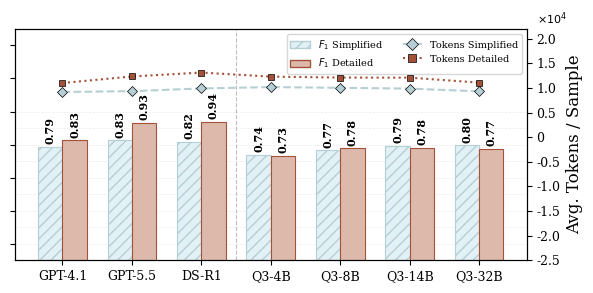

Saved to Fig/rq1_llm_f1_extrinsic.png


In [240]:
# ── RQ1: LLM-as-Expert F1 + Token Cost — Extrinsic ──

# Avg tokens per sample — extrinsic
model_tokens_binary_ext = {
    'GPT-4.1': 9187, 'GPT-5.5': 9356, 'DS-R1': 9904,
    'Qwen3-4B': 10180, 'Qwen3-8B': 10034, 'Qwen3-14B': 9872, 'Qwen3-32B': 9321,
}
model_tokens_scored_ext = {
    'GPT-4.1': 11011, 'GPT-5.5': 12337, 'DS-R1': 13130,
    'Qwen3-4B': 12308, 'Qwen3-8B': 12116, 'Qwen3-14B': 12094, 'Qwen3-32B': 11092,
}

fig, ax = plt.subplots(figsize=(6, FIG_H))
ax_c = ax.twinx()

x = np.arange(len(model_order))
setting = 'extr'

binary_vals = [results.get(m, {}).get(f'{setting}_binary', {}) for m in model_order]
scored_vals = [results.get(m, {}).get(f'{setting}_scored', {}) for m in model_order]
binary_vals = [r['f1'] if r else 0 for r in binary_vals]
scored_vals = [r['f1'] if r else 0 for r in scored_vals]

bs = bar_styles['binary']
bars1 = ax.bar(x - BAR_WIDTH/2, binary_vals, BAR_WIDTH,
               color=bs['facecolor'], edgecolor=bs['edgecolor'],
               hatch=bs['hatch'], linewidth=0.8, zorder=2)

ss = bar_styles['scored']
bars2 = ax.bar(x + BAR_WIDTH/2, scored_vals, BAR_WIDTH,
               color=ss['facecolor'], edgecolor=ss['edgecolor'],
               hatch=ss['hatch'], linewidth=0.8, zorder=2)

for bar, val in zip(bars1, binary_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')
for bar, val in zip(bars2, scored_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')

# Token cost lines — all models
tok_bin = [model_tokens_binary_ext.get(m, 0) for m in model_order]
tok_sco = [model_tokens_scored_ext.get(m, 0) for m in model_order]

ax_c.plot(x, tok_bin, color=COLORS['dark_cyan'], marker='D', markersize=5,
          linewidth=1.5, linestyle='--', zorder=5, markeredgecolor='black', markeredgewidth=0.5)
ax_c.plot(x, tok_sco, color=COLORS['red'], marker='s', markersize=5,
          linewidth=1.5, linestyle=':', zorder=5, markeredgecolor='black', markeredgewidth=0.5)


ax_c.set_ylim(-2.5e4, 2.2e4)
ax_c.set_yticks([-25000, -20000, -15000, -10000, -5000, 0, 5000, 10000, 15000, 20000])
ax_c.set_yticklabels(['-2.5', '-2.0', '-1.5', '-1.0', '-0.5', '0', '0.5', '1.0', '1.5', '2.0'])
ax_c.text(1.02, 1.01, r'$\times 10^4$', transform=ax_c.transAxes, fontsize=8, va='bottom', ha='left')
ax_c.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
ax_c.spines['right'].set_color('black')
ax_c.set_ylabel('Avg. Tokens / Sample', fontsize=FONT_SIZE_TICK, color='black')

ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
for y in np.arange(0, 1.1, 0.1):
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.15, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=0, ha='center', fontsize=TICK_LABEL_SIZE)
ax.set_ylabel('')
ax.set_yticklabels([])
ax.set_ylim(0.1, 1.5)
ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=bs['facecolor'], edgecolor=bs['edgecolor'], hatch=bs['hatch'], label='$F_1$ Simplified'),
    Patch(facecolor=ss['facecolor'], edgecolor=ss['edgecolor'], hatch=ss['hatch'], label='$F_1$ Detailed'),
    Line2D([0], [0], color=COLORS['dark_cyan'], marker='D', markersize=6, linestyle='--',
           markeredgecolor='black', markeredgewidth=0.5, label='Tokens Simplified'),
    Line2D([0], [0], color=COLORS['red'], marker='s', markersize=6, linestyle=':',
           markeredgecolor='black', markeredgewidth=0.5, label='Tokens Detailed'),
]
ax.legend(handles=legend_elements, loc='upper right', ncol=2, fontsize=7,
          frameon=True, edgecolor='lightgray', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rq1_llm_f1_extrinsic.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'rq1_llm_f1_extrinsic.pdf'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved to Fig/rq1_llm_f1_extrinsic.png')

## RQ2

In [241]:
# ── Inter-layer Fleiss' Kappa: split by Reference vs Mutated Negatives ──
def compute_kappa_subset(rater_names, all_raters, sample_filter_fn, label):
    """Compute Fleiss' kappa on a subset of samples filtered by sample_filter_fn."""
    common = [k for k in all_raters[rater_names[0]]
              if all(k in all_raters[r] and all_raters[r][k] is not None for r in rater_names)
              and sample_filter_fn(k)]
    if len(common) < 5:
        print(f'  {label}: too few samples ({len(common)})')
        return
    matrix = [[all_raters[r][k] for r in rater_names] for k in common]
    table, _ = aggregate_raters(matrix)
    kappa = _fleiss_kappa(table)
    print(f'  {label}: κ={kappa:.4f} (n={len(common)})')

print('='*70)
print('INTER-LAYER KAPPA — Split by Reference / Mutated Negatives')
print('='*70)

best_s3 = [r for r in all_raters if 'deepseek-reasoner' in r and 'Extr' in r and 'Detail' in r]

# S1 + S2 + Emb-Bal + best LLM
if best_s3 and 'S3-Emb-Intr-Bal' in all_raters:
    layers_4 = ['S1-Syntax', 'S2-Solvability', 'S3-Emb-Intr-Bal', best_s3[0]]
    print(f'\nRaters: {layers_4}')
    compute_kappa_subset(layers_4, all_raters, lambda k: k[0] == 'reference', 'Reference positives')
    compute_kappa_subset(layers_4, all_raters, lambda k: k[0] == 'bad', 'Mutated negatives')
    compute_kappa_subset(layers_4, all_raters, lambda k: True, 'All samples')

# ── On mutated negatives that PASSED S1+S2 (S3 evaluators only) ──
s1_preds = all_raters["S1-Syntax"]
s2_preds = all_raters["S2-Solvability"]
bad_passed_s1s2 = {k for k in s1_preds if k[0] == "bad" and s1_preds.get(k) == 1 and s2_preds.get(k) == 1}
print(f"Mutated negatives that passed S1+S2: {len(bad_passed_s1s2)}")

if best_s3 and "S3-Emb-Intr-Bal" in all_raters:
    s3_only = ["S1-Syntax", "S2-Solvability", "S3-Emb-Intr-Bal", best_s3[0]]
    common = [k for k in bad_passed_s1s2
              if all(k in all_raters[r] and all_raters[r][k] is not None for r in s3_only)]
    if len(common) >= 5:
        matrix = [[all_raters[r][k] for r in s3_only] for k in common]
        table, _ = aggregate_raters(matrix)
        kappa = _fleiss_kappa(table)
        print(f"  S1+S2+Emb-Bal+{best_s3[0]} on passed-S1S2 negatives: κ={kappa:.4f} (n={len(common)})")


INTER-LAYER KAPPA — Split by Reference / Mutated Negatives

Raters: ['S1-Syntax', 'S2-Solvability', 'S3-Emb-Intr-Bal', 'S3-LLM-Extr-Detail-deepseek-reasoner']
  Reference positives: κ=0.3272 (n=55)
  Mutated negatives: κ=-0.0659 (n=55)
  All samples: κ=0.1234 (n=110)
Mutated negatives that passed S1+S2: 47
  S1+S2+Emb-Bal+S3-LLM-Extr-Detail-deepseek-reasoner on passed-S1S2 negatives: κ=-0.2563 (n=47)
